# fmdins-02: Thailand Household Income Storytelling
**NSO Open Data | Mini-hackathon: From Data to Insight**

This second draft keeps the same three required questions, but presents them in a clearer storytelling flow: context, evidence, insight, and policy meaning.

**Questions covered**
1. **Who earns what?** Which occupation group has the highest and lowest average income?
2. **Where is inequality?** Which province shows the widest internal income gap?
3. **What is the income structure?** Which occupation groups are relatively more dependent on irregular income?


In [1]:
# Cell: Imports and display setup
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

try:
    from IPython.display import Markdown, display
except ImportError:

    def display(obj):
        print(obj)

    def Markdown(text):
        return text


pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 80)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["font.family"] = [
    "TH Sarabun New",
    "Sarabun",
    "Thonburi",
    "Arial Unicode MS",
    "DejaVu Sans",
]
plt.rcParams["axes.unicode_minus"] = False

print("Imports ready.")


Imports ready.


In [2]:
# Cell: Config
PROJECT_DIR = Path.cwd()
NOTEBOOK_SLUG = "fmdins-02-household-income-storytelling"
DATA_PATH = PROJECT_DIR / "data" / "avg_income.csv"
OUTPUT_DIR = (
    Path("/kaggle/working") if Path("/kaggle/working").exists() else PROJECT_DIR
)
TOTAL_INCOME_LABEL = "รายได้ทั้งสิ้นต่อเดือน"
REGULAR_LABEL = "รายได้ประจำ"
IRREGULAR_LABEL = "รายได้ไม่ประจำ (ที่เป็นตัวเงิน)"

print(f"NOTEBOOK_SLUG : {NOTEBOOK_SLUG}")
print(f"DATA_PATH     : {DATA_PATH}")
print(f"OUTPUT_DIR    : {OUTPUT_DIR}")


NOTEBOOK_SLUG : fmdins-02-household-income-storytelling
DATA_PATH     : /Users/beam/Workspace/Project/my-kaggle-notebooks/notebooks/2026-03-14-mini-hackathon-form-data-to-insight/data/avg_income.csv
OUTPUT_DIR    : /Users/beam/Workspace/Project/my-kaggle-notebooks/notebooks/2026-03-14-mini-hackathon-form-data-to-insight


In [3]:
# Cell: Load data preview
# The CSV uses a UTF-8 BOM, so utf-8-sig is required for a clean read.
df_raw = pd.read_csv(DATA_PATH, encoding="utf-8-sig")

print("Shape:", df_raw.shape)
print("\nDtypes:")
print(df_raw.dtypes)
display(df_raw.head(10))


Shape: (7700, 11)

Dtypes:
year                int64
province              str
source_income1        str
source_income2        str
source_income3        str
soc_eco_class1        str
soc_eco_class2        str
value             float64
unit                  str
attribute             str
source                str
dtype: object


,year,province,source_income1,source_income2,source_income3,soc_eco_class1,soc_eco_class2,value,unit,attribute,source
0,2566,กรุงเทพมหานคร,รายได้ทั้งสิ้นต่อเดือน,รายได้ทั้งสิ้นต่อเดือน,รายได้ทั้งสิ้นต่อเดือน,ผู้ถือครองทำการเกษตร/เพาะเลี้ยง,ปลูกพืช/เลี้ยงสัตว์/เพาะเลี้ยง_ส่วนใหญ่เป็นเจ้...,"29,549.00",บาท,NaN,สำนักงานสถิติแห่งชาติ
1,2566,กรุงเทพมหานคร,รายได้ประจำ,รายได้ประจำ,รายได้ประจำ,ผู้ถือครองทำการเกษตร/เพาะเลี้ยง,ปลูกพืช/เลี้ยงสัตว์/เพาะเลี้ยง_ส่วนใหญ่เป็นเจ้...,"29,549.00",บาท,NaN,สำนักงานสถิติแห่งชาติ
2,2566,กรุงเทพมหานคร,รายได้ประจำ,รายได้ที่เป็นตัวเงิน,รายได้ที่เป็นตัวเงิน,ผู้ถือครองทำการเกษตร/เพาะเลี้ยง,ปลูกพืช/เลี้ยงสัตว์/เพาะเลี้ยง_ส่วนใหญ่เป็นเจ้...,"23,925.00",บาท,NaN,สำนักงานสถิติแห่งชาติ
3,2566,กรุงเทพมหานคร,รายได้ประจำ,รายได้ที่เป็นตัวเงิน,ค่าจ้างและเงินเดือน,ผู้ถือครองทำการเกษตร/เพาะเลี้ยง,ปลูกพืช/เลี้ยงสัตว์/เพาะเลี้ยง_ส่วนใหญ่เป็นเจ้...,0.00,บาท,ศูนย์ยกกำลังดับเบิลยู หมายถึง ข้อมูลจากการสำรว...,สำนักงานสถิติแห่งชาติ
4,2566,กรุงเทพมหานคร,รายได้ประจำ,รายได้ที่เป็นตัวเงิน,กำไรสุทธิจากการทำธุรกิจ,ผู้ถือครองทำการเกษตร/เพาะเลี้ยง,ปลูกพืช/เลี้ยงสัตว์/เพาะเลี้ยง_ส่วนใหญ่เป็นเจ้...,0.00,บาท,ศูนย์ยกกำลังดับเบิลยู หมายถึง ข้อมูลจากการสำรว...,สำนักงานสถิติแห่งชาติ
5,2566,กรุงเทพมหานคร,รายได้ประจำ,รายได้ที่เป็นตัวเงิน,กำไรสุทธิจากการทำการเกษตร,ผู้ถือครองทำการเกษตร/เพาะเลี้ยง,ปลูกพืช/เลี้ยงสัตว์/เพาะเลี้ยง_ส่วนใหญ่เป็นเจ้...,"23,925.00",บาท,NaN,สำนักงานสถิติแห่งชาติ
6,2566,กรุงเทพมหานคร,รายได้ประจำ,รายได้ที่เป็นตัวเงิน,เงินที่ได้รับเป็นการช่วยเหลือ,ผู้ถือครองทำการเกษตร/เพาะเลี้ยง,ปลูกพืช/เลี้ยงสัตว์/เพาะเลี้ยง_ส่วนใหญ่เป็นเจ้...,0.00,บาท,ศูนย์ยกกำลังดับเบิลยู หมายถึง ข้อมูลจากการสำรว...,สำนักงานสถิติแห่งชาติ
7,2566,กรุงเทพมหานคร,รายได้ประจำ,รายได้ที่เป็นตัวเงิน,รายได้จากทรัพย์สิน,ผู้ถือครองทำการเกษตร/เพาะเลี้ยง,ปลูกพืช/เลี้ยงสัตว์/เพาะเลี้ยง_ส่วนใหญ่เป็นเจ้...,0.00,บาท,ศูนย์ยกกำลังดับเบิลยู หมายถึง ข้อมูลจากการสำรว...,สำนักงานสถิติแห่งชาติ
8,2566,กรุงเทพมหานคร,รายได้ประจำ,รายได้ที่ไม่เป็นตัวเงิน,รายได้ที่ไม่เป็นตัวเงิน,ผู้ถือครองทำการเกษตร/เพาะเลี้ยง,ปลูกพืช/เลี้ยงสัตว์/เพาะเลี้ยง_ส่วนใหญ่เป็นเจ้...,"5,624.00",บาท,NaN,สำนักงานสถิติแห่งชาติ
9,2566,กรุงเทพมหานคร,รายได้ไม่ประจำ (ที่เป็นตัวเงิน),รายได้ไม่ประจำ (ที่เป็นตัวเงิน),รายได้ไม่ประจำ (ที่เป็นตัวเงิน),ผู้ถือครองทำการเกษตร/เพาะเลี้ยง,ปลูกพืช/เลี้ยงสัตว์/เพาะเลี้ยง_ส่วนใหญ่เป็นเจ้...,0.00,บาท,ศูนย์ยกกำลังดับเบิลยู หมายถึง ข้อมูลจากการสำรว...,สำนักงานสถิติแห่งชาติ


In [4]:
# Cell: Cleaning log and derived columns
df = df_raw.copy()

null_counts = df.isna().sum()
duplicate_rows = int(df.duplicated().sum())
total_rows = len(df)
year_min = int(df["year"].min())
year_max = int(df["year"].max())

df["value"] = pd.to_numeric(df["value"], errors="coerce")
df["year_ce"] = df["year"] - 543
df["is_zero"] = df["value"].eq(0)
df["is_negative"] = df["value"].lt(0)

zero_rows = int(df["is_zero"].sum())
negative_rows = int(df["is_negative"].sum())
flagged_rows = int(df["attribute"].notna().sum())

cleaning_log = [
    {
        "check": "BOM encoding",
        "finding": "UTF-8 BOM present at file start",
        "action_taken": "Loaded with encoding='utf-8-sig'",
        "rows_affected": "all",
    },
    {
        "check": "Null values",
        "finding": f"attribute has {int(null_counts['attribute']):,} nulls; core analysis fields have no nulls",
        "action_taken": "Retained attribute nulls as informational",
        "rows_affected": int(null_counts["attribute"]),
    },
    {
        "check": "Duplicate rows",
        "finding": f"{duplicate_rows} duplicate rows found",
        "action_taken": "No rows dropped",
        "rows_affected": duplicate_rows,
    },
    {
        "check": "Year format",
        "finding": f"Dataset year uses Buddhist Era values {year_min} to {year_max}",
        "action_taken": "Added year_ce = year - 543",
        "rows_affected": "all",
    },
    {
        "check": "Zero values",
        "finding": f"{zero_rows:,} rows have value == 0",
        "action_taken": "Added is_zero flag and excluded them from analytical aggregates",
        "rows_affected": zero_rows,
    },
    {
        "check": "Negative values",
        "finding": f"{negative_rows} rows have negative income values; minimum is {df['value'].min():,.0f}",
        "action_taken": "Retained values because they are part of the published source and may reflect adjustments/special cases",
        "rows_affected": negative_rows,
    },
    {
        "check": "Special-value notes",
        "finding": f"attribute is populated in {flagged_rows:,} rows",
        "action_taken": "Kept attribute column for transparency",
        "rows_affected": flagged_rows,
    },
    {
        "check": "Scope",
        "finding": f"Cross-sectional dataset with {df['province'].nunique()} provinces and {df['soc_eco_class2'].nunique()} occupation groups",
        "action_taken": "Analysis focuses on 2023 structure rather than time trends",
        "rows_affected": "all",
    },
]

cleaning_log_df = pd.DataFrame(cleaning_log)
display(cleaning_log_df)
print(f"Rows in raw data: {total_rows:,}")
print(f"Columns added: year_ce, is_zero, is_negative")


,check,finding,action_taken,rows_affected
0,BOM encoding,UTF-8 BOM present at file start,Loaded with encoding='utf-8-sig',all
1,Null values,"attribute has 6,865 nulls; core analysis field...",Retained attribute nulls as informational,6865
2,Duplicate rows,0 duplicate rows found,No rows dropped,0
3,Year format,Dataset year uses Buddhist Era values 2566 to ...,Added year_ce = year - 543,all
4,Zero values,835 rows have value == 0,Added is_zero flag and excluded them from anal...,835
5,Negative values,36 rows have negative income values; minimum i...,Retained values because they are part of the p...,36
6,Special-value notes,attribute is populated in 835 rows,Kept attribute column for transparency,835
7,Scope,Cross-sectional dataset with 77 provinces and ...,Analysis focuses on 2023 structure rather than...,all


Rows in raw data: 7,700
Columns added: year_ce, is_zero, is_negative


In [5]:
# Cell: Hierarchy exploration and filter guide
for col in ["source_income1", "source_income2", "source_income3"]:
    print(f"\n=== {col} ===")
    print(df[col].value_counts().to_string())

for col in ["soc_eco_class1", "soc_eco_class2"]:
    print(f"\n=== {col} ===")
    print(df[col].value_counts().to_string())

display(
    Markdown(
        """
**Filter guide used in this notebook**

- **Q1 Who earns what?** Use `source_income3 == TOTAL_INCOME_LABEL` and exclude zero rows.
- **Q2 Where is inequality?** Use the same total-income filter, then compare occupation-level income spread within each province.
- **Q3 What is the income structure?** Compare `รายได้ประจำ` with `รายได้ไม่ประจำ (ที่เป็นตัวเงิน)` to show regular versus irregular income composition.
"""
    )
)



=== source_income1 ===
source_income1
รายได้ประจำ                        6160
รายได้ทั้งสิ้นต่อเดือน              770
รายได้ไม่ประจำ (ที่เป็นตัวเงิน)     770

=== source_income2 ===
source_income2
รายได้ที่เป็นตัวเงิน               4620
รายได้ทั้งสิ้นต่อเดือน              770
รายได้ประจำ                         770
รายได้ที่ไม่เป็นตัวเงิน             770
รายได้ไม่ประจำ (ที่เป็นตัวเงิน)     770

=== source_income3 ===
source_income3
รายได้ทั้งสิ้นต่อเดือน             770
รายได้ประจำ                        770
รายได้ที่เป็นตัวเงิน               770
ค่าจ้างและเงินเดือน                770
กำไรสุทธิจากการทำธุรกิจ            770
กำไรสุทธิจากการทำการเกษตร          770
เงินที่ได้รับเป็นการช่วยเหลือ      770
รายได้จากทรัพย์สิน                 770
รายได้ที่ไม่เป็นตัวเงิน            770
รายได้ไม่ประจำ (ที่เป็นตัวเงิน)    770

=== soc_eco_class1 ===
soc_eco_class1
ลูกจ้าง                                     3850
ผู้ถือครองทำการเกษตร/เพาะเลี้ยง             2310
ผู้ประกอบธุรกิจของตนเองที่ไม่ใช่การเ


**Filter guide used in this notebook**

- **Q1 Who earns what?** Use `source_income3 == TOTAL_INCOME_LABEL` and exclude zero rows.
- **Q2 Where is inequality?** Use the same total-income filter, then compare occupation-level income spread within each province.
- **Q3 What is the income structure?** Compare `รายได้ประจำ` with `รายได้ไม่ประจำ (ที่เป็นตัวเงิน)` to show regular versus irregular income composition.


In [6]:
# Cell: Province to region mapping
REGION_MAP = {
    "กรุงเทพมหานคร": "Bangkok",
    "สมุทรปราการ": "Central",
    "นนทบุรี": "Central",
    "ปทุมธานี": "Central",
    "พระนครศรีอยุธยา": "Central",
    "อ่างทอง": "Central",
    "ลพบุรี": "Central",
    "สิงห์บุรี": "Central",
    "ชัยนาท": "Central",
    "สระบุรี": "Central",
    "นครปฐม": "Central",
    "สมุทรสาคร": "Central",
    "สมุทรสงคราม": "Central",
    "ราชบุรี": "Central",
    "กาญจนบุรี": "Central",
    "สุพรรณบุรี": "Central",
    "นครสวรรค์": "Central",
    "อุทัยธานี": "Central",
    "กำแพงเพชร": "Central",
    "ตาก": "Central",
    "เพชรบุรี": "Central",
    "ประจวบคีรีขันธ์": "Central",
    "ชลบุรี": "East",
    "ระยอง": "East",
    "จันทบุรี": "East",
    "ตราด": "East",
    "ฉะเชิงเทรา": "East",
    "ปราจีนบุรี": "East",
    "นครนายก": "East",
    "สระแก้ว": "East",
    "เชียงใหม่": "North",
    "ลำพูน": "North",
    "ลำปาง": "North",
    "อุตรดิตถ์": "North",
    "แพร่": "North",
    "น่าน": "North",
    "พะเยา": "North",
    "เชียงราย": "North",
    "แม่ฮ่องสอน": "North",
    "สุโขทัย": "North",
    "พิษณุโลก": "North",
    "พิจิตร": "North",
    "เพชรบูรณ์": "North",
    "นครราชสีมา": "Northeast",
    "บุรีรัมย์": "Northeast",
    "สุรินทร์": "Northeast",
    "ศรีสะเกษ": "Northeast",
    "อุบลราชธานี": "Northeast",
    "ยโสธร": "Northeast",
    "ชัยภูมิ": "Northeast",
    "อำนาจเจริญ": "Northeast",
    "บึงกาฬ": "Northeast",
    "หนองบัวลำภู": "Northeast",
    "ขอนแก่น": "Northeast",
    "อุดรธานี": "Northeast",
    "เลย": "Northeast",
    "หนองคาย": "Northeast",
    "มหาสารคาม": "Northeast",
    "ร้อยเอ็ด": "Northeast",
    "กาฬสินธุ์": "Northeast",
    "สกลนคร": "Northeast",
    "นครพนม": "Northeast",
    "มุกดาหาร": "Northeast",
    "นครศรีธรรมราช": "South",
    "กระบี่": "South",
    "พังงา": "South",
    "ภูเก็ต": "South",
    "สุราษฎร์ธานี": "South",
    "ระนอง": "South",
    "ชุมพร": "South",
    "สงขลา": "South",
    "สตูล": "South",
    "ตรัง": "South",
    "พัทลุง": "South",
    "ปัตตานี": "South",
    "ยะลา": "South",
    "นราธิวาส": "South",
}

REGION_COLORS = {
    "Bangkok": "#c1121f",
    "Central": "#3a86ff",
    "East": "#00b894",
    "North": "#f4a261",
    "Northeast": "#8d5fd3",
    "South": "#2a9d8f",
}

df["region"] = df["province"].map(REGION_MAP)
unmapped = sorted(df.loc[df["region"].isna(), "province"].drop_duplicates().tolist())

print("Unmapped provinces:", unmapped)
display(
    df.drop_duplicates("province")["region"]
    .value_counts(dropna=False)
    .rename_axis("region")
    .reset_index(name="province_count")
)


Unmapped provinces: []


,region,province_count
0,Central,21
1,Northeast,20
2,South,14
3,North,13
4,East,8
5,Bangkok,1


## EDA — Distribution and headline KPIs

Before answering the three questions, this section checks the national distribution. The aim is to spot whether the dataset is balanced, skewed, or affected by unusual values before moving into ranked comparisons.


,national_avg_income,national_median_income,min_income,max_income,income_range,province_count,occupation_group_count
0,"26,177.19","22,824.00",-600.00,"181,322.00","181,922.00",77,10


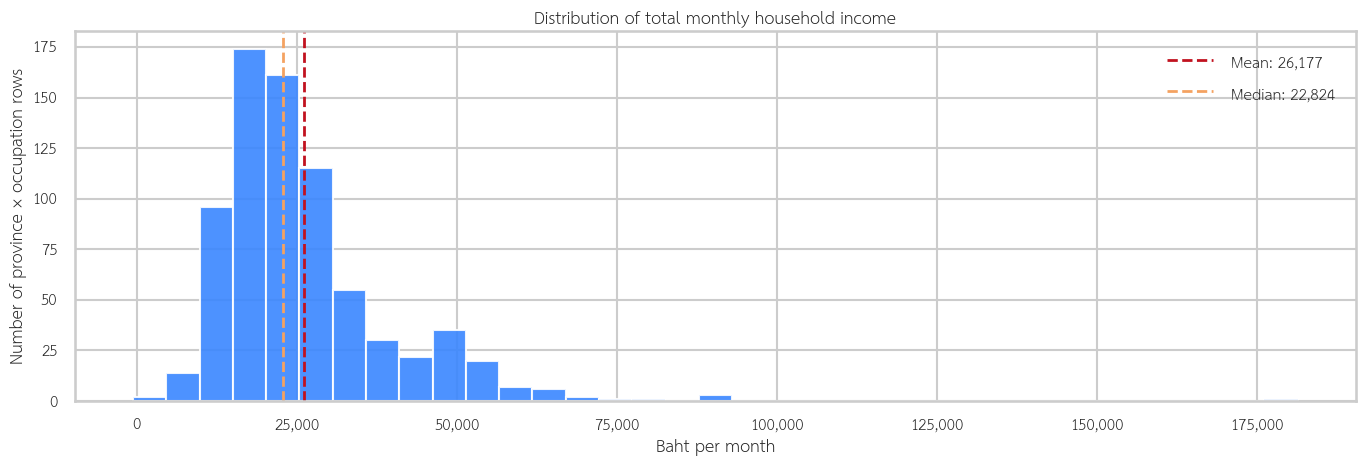


**EDA takeaway**

- The distribution is right-skewed: the national mean is **26,177 baht**, above the median of **22,824 baht**.
- The minimum value is **-600 baht**, so the dataset includes a few unusual or adjusted observations that should be interpreted carefully.
- This raises two deeper questions for the main analysis: which occupation groups drive the top end of the distribution, and which provinces combine high averages with wide internal gaps?


In [7]:
# Cell: EDA and KPI summary
df_total = df[(df["source_income3"] == TOTAL_INCOME_LABEL) & (~df["is_zero"])].copy()

kpi_df = pd.DataFrame(
    [
        {
            "national_avg_income": df_total["value"].mean(),
            "national_median_income": df_total["value"].median(),
            "min_income": df_total["value"].min(),
            "max_income": df_total["value"].max(),
            "income_range": df_total["value"].max() - df_total["value"].min(),
            "province_count": df_total["province"].nunique(),
            "occupation_group_count": df_total["soc_eco_class2"].nunique(),
        }
    ]
)
display(kpi_df)

fig, ax = plt.subplots(figsize=(14, 5))
ax.hist(df_total["value"], bins=35, color="#3a86ff", edgecolor="white", alpha=0.9)
ax.axvline(
    df_total["value"].mean(),
    color="#c1121f",
    linestyle="--",
    linewidth=2,
    label=f"Mean: {df_total['value'].mean():,.0f}",
)
ax.axvline(
    df_total["value"].median(),
    color="#f4a261",
    linestyle="--",
    linewidth=2,
    label=f"Median: {df_total['value'].median():,.0f}",
)
ax.set_title("Distribution of total monthly household income")
ax.set_xlabel("Baht per month")
ax.set_ylabel("Number of province × occupation rows")
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

display(
    Markdown(
        f"""
**EDA takeaway**

- The distribution is right-skewed: the national mean is **{df_total["value"].mean():,.0f} baht**, above the median of **{df_total["value"].median():,.0f} baht**.
- The minimum value is **{df_total["value"].min():,.0f} baht**, so the dataset includes a few unusual or adjusted observations that should be interpreted carefully.
- This raises two deeper questions for the main analysis: which occupation groups drive the top end of the distribution, and which provinces combine high averages with wide internal gaps?
"""
    )
)


## Question 1 — Who earns what?

**Why this chart:** a sorted horizontal bar chart makes the ranking immediately visible while still allowing color grouping by broad occupation class.


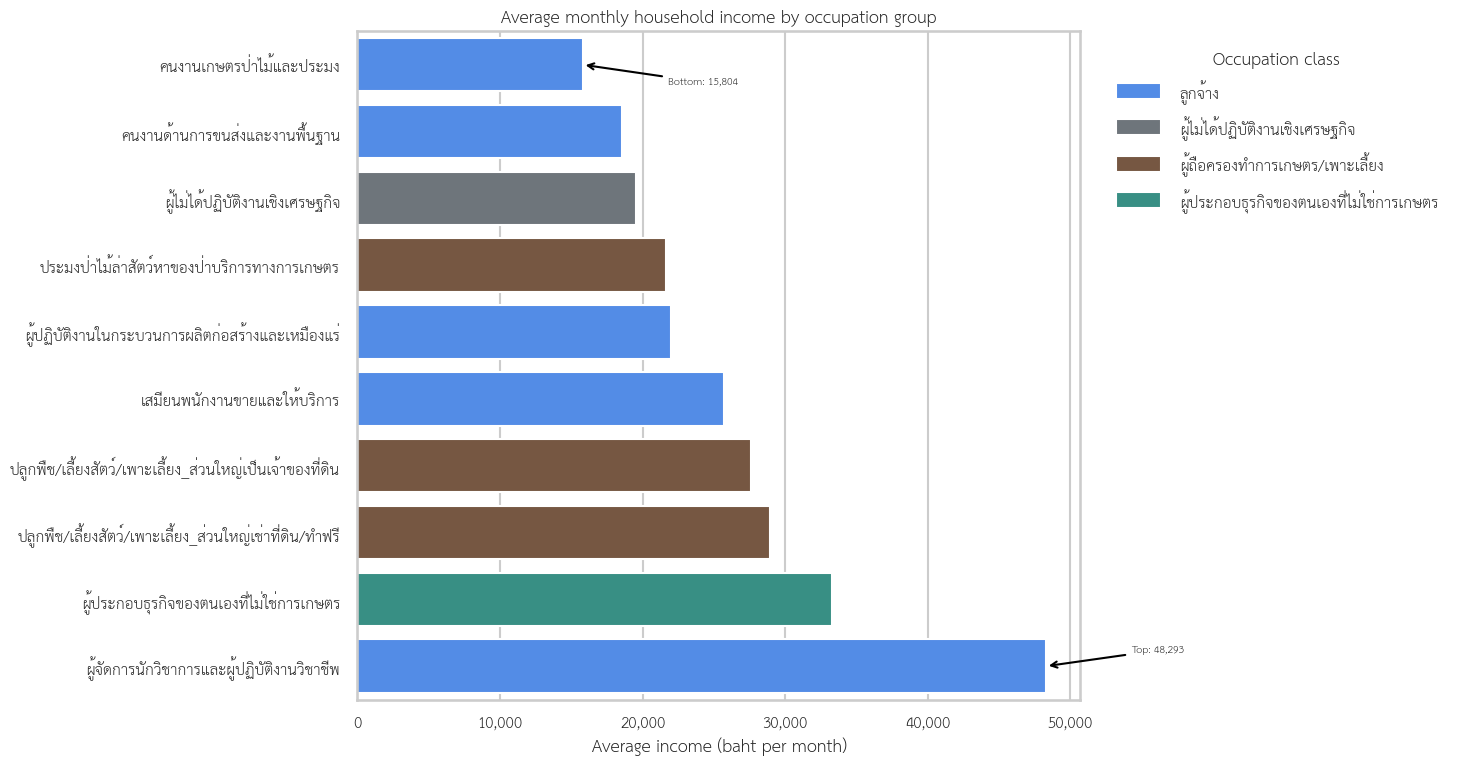


**Q1 takeaway**

- The highest average income belongs to **ผู้จัดการนักวิชาการและผู้ปฏิบัติงานวิชาชีพ** at **48,293 baht/month**.
- The lowest average income belongs to **คนงานเกษตรป่าไม้และประมง** at **15,804 baht/month**.
- The gap is **32,489 baht/month**, or about **3.1x** from top to bottom.


In [8]:
# Cell: Q1 analysis
q1_df = (
    df_total.groupby(["soc_eco_class1", "soc_eco_class2"], as_index=False)["value"]
    .mean()
    .sort_values("value", ascending=True)
)

class_palette = {
    "ผู้ถือครองทำการเกษตร/เพาะเลี้ยง": "#7f5539",
    "ผู้ประกอบธุรกิจของตนเองที่ไม่ใช่การเกษตร": "#2a9d8f",
    "ลูกจ้าง": "#3a86ff",
    "ผู้ไม่ได้ปฏิบัติงานเชิงเศรษฐกิจ": "#6c757d",
}

fig, ax = plt.subplots(figsize=(15, 8))
sns.barplot(
    data=q1_df,
    x="value",
    y="soc_eco_class2",
    hue="soc_eco_class1",
    dodge=False,
    palette=class_palette,
    ax=ax,
)
ax.set_title("Average monthly household income by occupation group")
ax.set_xlabel("Average income (baht per month)")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
ax.legend(
    title="Occupation class", frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left"
)

highest = q1_df.iloc[-1]
lowest = q1_df.iloc[0]
income_gap = highest["value"] - lowest["value"]
income_ratio = highest["value"] / lowest["value"]

ax.annotate(
    f"Top: {highest['value']:,.0f}",
    xy=(highest["value"], len(q1_df) - 1),
    xytext=(highest["value"] + 6000, len(q1_df) - 1.2),
    arrowprops={"arrowstyle": "->", "color": "black"},
    fontsize=11,
)
ax.annotate(
    f"Bottom: {lowest['value']:,.0f}",
    xy=(lowest["value"], 0),
    xytext=(lowest["value"] + 6000, 0.3),
    arrowprops={"arrowstyle": "->", "color": "black"},
    fontsize=11,
)
plt.tight_layout()
plt.show()

display(
    Markdown(
        f"""
**Q1 takeaway**

- The highest average income belongs to **{highest["soc_eco_class2"]}** at **{highest["value"]:,.0f} baht/month**.
- The lowest average income belongs to **{lowest["soc_eco_class2"]}** at **{lowest["value"]:,.0f} baht/month**.
- The gap is **{income_gap:,.0f} baht/month**, or about **{income_ratio:.1f}x** from top to bottom.
"""
    )
)


## Question 2 — Where is inequality?

**Why these charts:** the ranked bar chart shows which provinces have the largest internal gap, while the scatter plot shows whether high average income and high inequality tend to appear together.


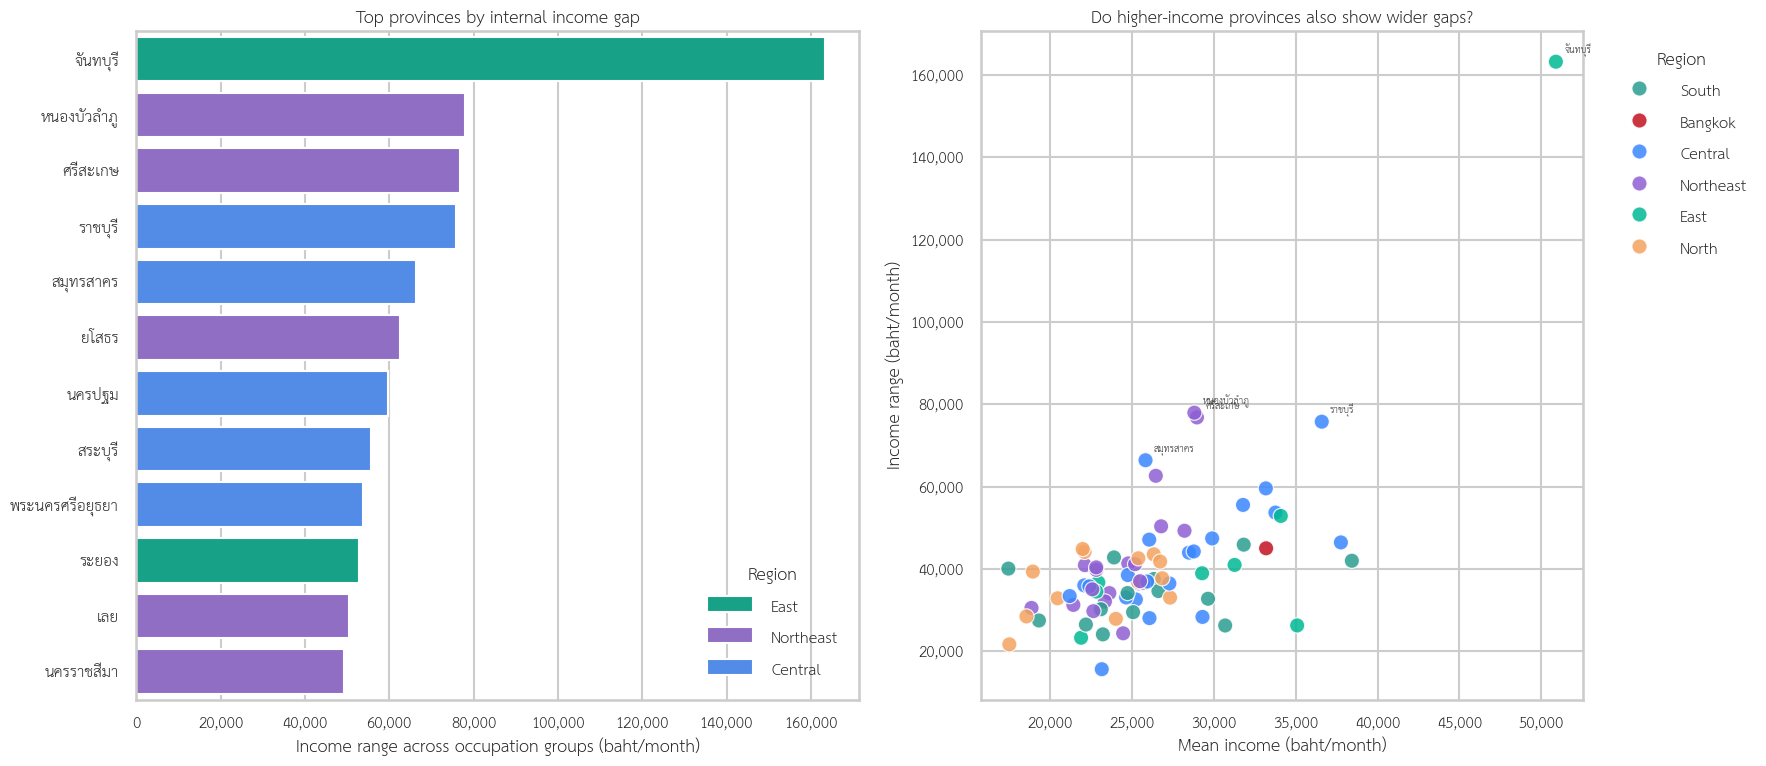


**Q2 takeaway**

- **จันทบุรี** shows the widest internal income gap at **163,230 baht/month**.
- Its average income is **50,893 baht/month**, which shows that high earning power and high inequality can coexist.
- Several of the highest-gap provinces come from **Central**, **East**, and **Northeast** areas, suggesting that place-based policy should focus not only on raising income, but also on narrowing local disparities.


In [9]:
# Cell: Q2 analysis
df_latest = df_total[df_total["year_ce"] == df_total["year_ce"].max()].copy()

province_stats = (
    df_latest.groupby("province")["value"]
    .agg(
        mean_income="mean",
        max_income="max",
        min_income="min",
        income_range=lambda x: x.max() - x.min(),
        cv=lambda x: x.std(ddof=0) / x.mean(),
    )
    .reset_index()
)
province_stats["region"] = province_stats["province"].map(REGION_MAP)

top_provinces = (
    province_stats.sort_values("income_range", ascending=False).head(12).copy()
)

fig, axes = plt.subplots(1, 2, figsize=(18, 8), gridspec_kw={"width_ratios": [1.2, 1]})

sns.barplot(
    data=top_provinces,
    x="income_range",
    y="province",
    hue="region",
    dodge=False,
    palette=REGION_COLORS,
    ax=axes[0],
)
axes[0].set_title("Top provinces by internal income gap")
axes[0].set_xlabel("Income range across occupation groups (baht/month)")
axes[0].set_ylabel("")
axes[0].xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
axes[0].legend(title="Region", frameon=False, loc="lower right")

sns.scatterplot(
    data=province_stats,
    x="mean_income",
    y="income_range",
    hue="region",
    palette=REGION_COLORS,
    s=120,
    alpha=0.85,
    ax=axes[1],
)
axes[1].set_title("Do higher-income provinces also show wider gaps?")
axes[1].set_xlabel("Mean income (baht/month)")
axes[1].set_ylabel("Income range (baht/month)")
axes[1].xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
axes[1].yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))

label_df = province_stats.sort_values("income_range", ascending=False).head(5)
for _, row in label_df.iterrows():
    axes[1].annotate(
        row["province"],
        (row["mean_income"], row["income_range"]),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=10,
    )

axes[1].legend(
    title="Region", frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left"
)
plt.tight_layout()
plt.show()

most_unequal = province_stats.sort_values("income_range", ascending=False).iloc[0]
display(
    Markdown(
        f"""
**Q2 takeaway**

- **{most_unequal["province"]}** shows the widest internal income gap at **{most_unequal["income_range"]:,.0f} baht/month**.
- Its average income is **{most_unequal["mean_income"]:,.0f} baht/month**, which shows that high earning power and high inequality can coexist.
- Several of the highest-gap provinces come from **Central**, **East**, and **Northeast** areas, suggesting that place-based policy should focus not only on raising income, but also on narrowing local disparities.
"""
    )
)


## Question 3 — What is the income structure?

**Why this chart:** a 100% stacked bar removes scale differences and focuses attention on composition, which is the main question here.


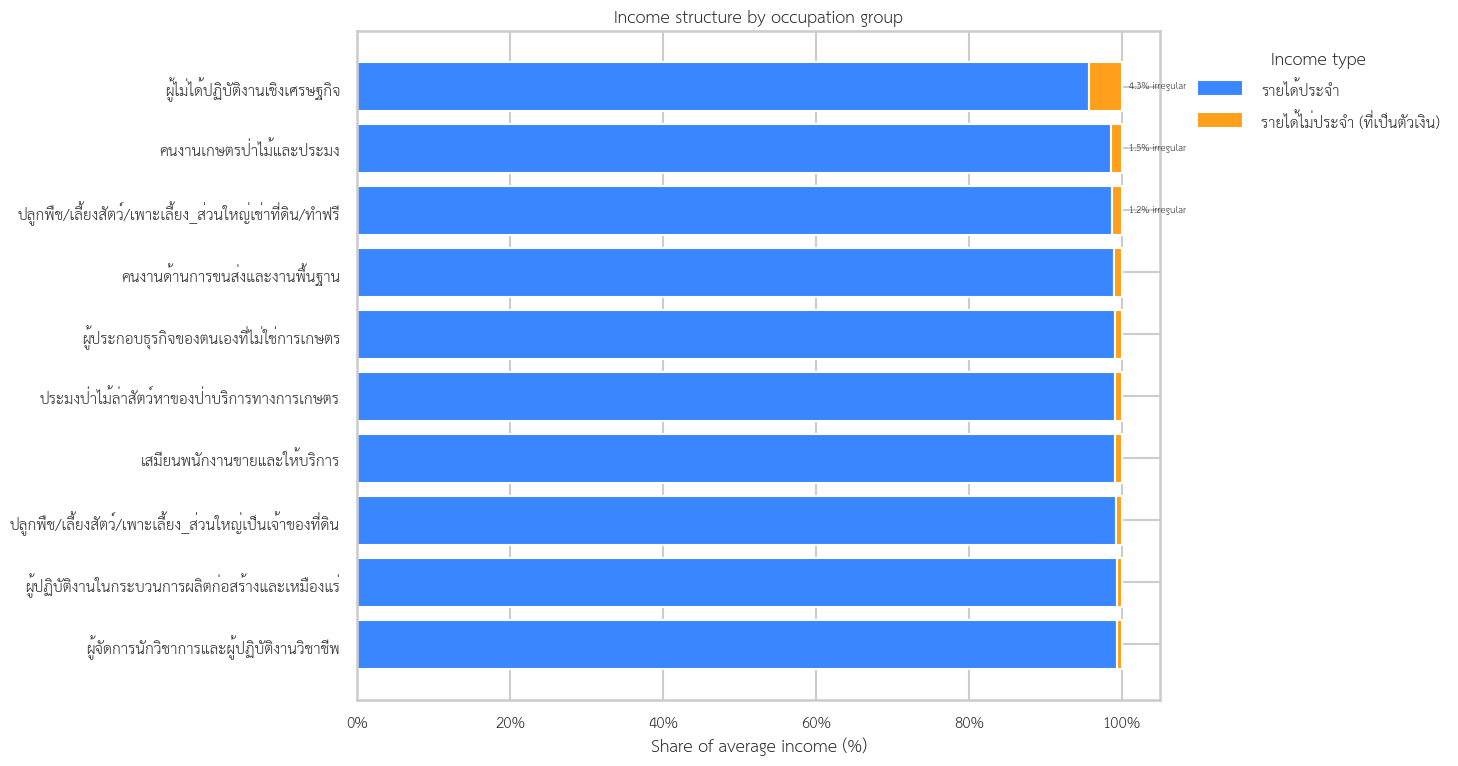


**Q3 takeaway**

- The occupation group with the highest irregular-income share is **ผู้ไม่ได้ปฏิบัติงานเชิงเศรษฐกิจ** at **4.3%**.
- Even the highest group is still dominated by regular income, so this dataset suggests that the bigger structural issue is **income level and inequality**, not extreme irregular dependence.
- Still, relative differences matter: the groups with the largest irregular shares are the ones that may be more exposed to unstable cash flow when shocks occur.


In [10]:
# Cell: Q3 analysis
df_structure = df[
    (df["source_income3"].isin([REGULAR_LABEL, IRREGULAR_LABEL])) & (~df["is_zero"])
].copy()

pivot = (
    df_structure.groupby(["soc_eco_class2", "source_income3"])["value"]
    .mean()
    .unstack(fill_value=0)
)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
pivot_pct = pivot_pct.sort_values(IRREGULAR_LABEL, ascending=True)

fig, ax = plt.subplots(figsize=(15, 8))
left = np.zeros(len(pivot_pct))
structure_colors = {
    REGULAR_LABEL: "#3a86ff",
    IRREGULAR_LABEL: "#ff9f1c",
}

for column in [REGULAR_LABEL, IRREGULAR_LABEL]:
    values = pivot_pct[column].to_numpy()
    ax.barh(
        pivot_pct.index, values, left=left, label=column, color=structure_colors[column]
    )
    left += values

ax.set_title("Income structure by occupation group")
ax.set_xlabel("Share of average income (%)")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(
    title="Income type", frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left"
)

top_irregular = pivot_pct.sort_values(IRREGULAR_LABEL, ascending=False).head(3)
for idx, (_, row) in enumerate(top_irregular.iterrows()):
    ax.text(
        101,
        len(pivot_pct) - idx - 1,
        f"{row[IRREGULAR_LABEL]:.1f}% irregular",
        va="center",
        fontsize=10,
    )

plt.tight_layout()
plt.show()

highest_irregular_group = top_irregular.index[0]
highest_irregular_share = top_irregular.iloc[0][IRREGULAR_LABEL]
display(
    Markdown(
        f"""
**Q3 takeaway**

- The occupation group with the highest irregular-income share is **{highest_irregular_group}** at **{highest_irregular_share:.1f}%**.
- Even the highest group is still dominated by regular income, so this dataset suggests that the bigger structural issue is **income level and inequality**, not extreme irregular dependence.
- Still, relative differences matter: the groups with the largest irregular shares are the ones that may be more exposed to unstable cash flow when shocks occur.
"""
    )
)


## Key Insights

### Q1 — Who earns what?
**What:** The highest-earning occupation group is managers, professionals, and technical workers, while agricultural labor groups sit at the bottom of the ranking.

**Why:** Occupation groups with stronger formal labor-market positioning and skill premiums capture much higher monthly income than groups tied to low-wage or seasonal work.

**So What:** Income policy should not treat all workers as one category. The lowest-income occupational groups need targeted support, skill-building, and better earnings protection.

### Q2 — Where is inequality?
**What:** Provinces such as Chanthaburi show very wide internal income gaps, meaning high-income and low-income groups coexist in the same place.

**Why:** Places with stronger commercial or urban activity can combine high-paying occupation groups with much lower-paying service, agricultural, or basic labor roles.

**So What:** Regional policy should not focus only on provincial averages. Provinces with wide internal gaps need inclusion-focused local interventions alongside growth policy.

### Q3 — What is the income structure?
**What:** Regular income dominates across all occupation groups, though some groups still show relatively higher irregular-income shares than others.

**Why:** In this dataset, irregular income is a smaller component overall, but relative differences still help identify groups that may face less predictable cash flow.

**So What:** For this dataset, the most urgent policy story is not extreme irregular dependence by itself, but how lower-income and relatively less stable groups may be hit harder by income shocks.
